In [24]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
# ==========================================
# SUPABASE CONNECTION CONFIG
# ==========================================
os.environ["SUPABASE_DB_PASSWORD"] = "Bonabosssfs01"
SUPABASE_HOST = "aws-1-eu-central-1.pooler.supabase.com"
SUPABASE_PORT = "5432"
SUPABASE_DB = "postgres"
SUPABASE_USER = "postgres.ogkdfmkybqtrsglcizzt"
SUPABASE_PASSWORD = os.getenv("SUPABASE_DB_PASSWORD")

if not SUPABASE_PASSWORD:
    raise ValueError("❌ SUPABASE_DB_PASSWORD is not set in environment variables")

# Connection string
DATABASE_URL = f"postgresql+psycopg2://{SUPABASE_USER}:{SUPABASE_PASSWORD}@{SUPABASE_HOST}:{SUPABASE_PORT}/{SUPABASE_DB}"

# Engine (VERY IMPORTANT SETTINGS)
engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,   # fixes stale connection issues
    pool_recycle=300      # avoids Supabase killing idle connections
)

print("✅ Engine created successfully")

✅ Engine created successfully


In [9]:
with engine.connect() as conn:
    result = conn.execute(text("SELECT 1"))
    print("✅ Connection test passed:", result.scalar())

✅ Connection test passed: 1


In [10]:
tables = [
    "dim_calendar", "dim_stores", "dim_products", "dim_policy_regimes",
    "fact_sales", "fact_inventory", "fact_weather",
    "fact_promotions", "fact_customer_activity",
    "fact_store_operations", "fact_restriction_events"
]

for table in tables:
    df = pd.read_sql(f"SELECT COUNT(*) AS rows FROM core.{table}", engine)
    print(table, ":", f"{df['rows'][0]:,}")

dim_calendar : 1,943
dim_stores : 7
dim_products : 120
dim_policy_regimes : 4
fact_sales : 1,632,120
fact_inventory : 1,632,120
fact_weather : 13,601
fact_promotions : 380
fact_customer_activity : 13,601
fact_store_operations : 13,601
fact_restriction_events : 22,002


In [11]:
for table in [
    "dim_calendar",
    "fact_sales",
    "fact_inventory",
    "fact_weather",
    "fact_customer_activity",
    "fact_store_operations",
    "fact_restriction_events"
]:
    df = pd.read_sql(f"""
        SELECT MIN(date) AS min_date, MAX(date) AS max_date, COUNT(*) AS rows
        FROM core.{table}
    """, engine)
    print(table)
    print(df)
    print()

dim_calendar
    min_date   max_date  rows
0 2021-01-01 2026-04-27  1943

fact_sales
    min_date   max_date     rows
0 2021-01-01 2026-04-27  1632120

fact_inventory
    min_date   max_date     rows
0 2021-01-01 2026-04-27  1632120

fact_weather
    min_date   max_date   rows
0 2021-01-01 2026-04-27  13601

fact_customer_activity
    min_date   max_date   rows
0 2021-01-01 2026-04-27  13601

fact_store_operations
    min_date   max_date   rows
0 2021-01-01 2026-04-27  13601

fact_restriction_events
    min_date   max_date   rows
0 2021-01-01 2026-04-27  22002



In [12]:
df_check = pd.read_sql("""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT date) AS unique_dates,
        COUNT(DISTINCT store_id) AS unique_stores,
        COUNT(DISTINCT product_id) AS unique_products,
        SUM(units_sold) AS total_units_sold,
        SUM(revenue) AS total_revenue,
        AVG(revenue) AS avg_row_revenue,
        MAX(revenue) AS max_row_revenue
    FROM core.fact_sales
""", engine)

df_check

,rows,unique_dates,unique_stores,unique_products,total_units_sold,total_revenue,avg_row_revenue,max_row_revenue
0,1632120,1943,7,120,3521586.0,1.890468e+11,115829.009075,2344070.0


In [16]:
print(df_check)

      rows  unique_dates  unique_stores  unique_products  total_units_sold  \
0  1632120          1943              7              120         3521586.0   

   total_revenue  avg_row_revenue  max_row_revenue  
0   1.890468e+11    115829.009075        2344070.0  


In [13]:
monthly_revenue = pd.read_sql("""
    SELECT
        DATE_TRUNC('month', date)::date AS month,
        SUM(revenue) AS total_revenue,
        SUM(units_sold) AS total_units_sold
    FROM core.fact_sales
    GROUP BY 1
    ORDER BY 1
""", engine)

monthly_revenue.head()

,month,total_revenue,total_units_sold
0,2021-01-01,3.192953e+09,57192.0
1,2021-02-01,2.785990e+09,49626.0
2,2021-03-01,2.963566e+09,54775.0
3,2021-04-01,2.858082e+09,53679.0
4,2021-05-01,2.988947e+09,56414.0


In [14]:
monthly_revenue.shape

(64, 3)

In [21]:
pd.set_option('display.max_rows', None)
monthly_revenue

,month,total_revenue,total_units_sold
0,2021-01-01,3.192953e+09,57192.0
1,2021-02-01,2.785990e+09,49626.0
2,2021-03-01,2.963566e+09,54775.0
3,2021-04-01,2.858082e+09,53679.0
4,2021-05-01,2.988947e+09,56414.0
5,2021-06-01,2.806938e+09,53063.0
6,2021-07-01,2.890091e+09,55117.0
7,2021-08-01,2.926931e+09,55064.0
8,2021-09-01,2.946596e+09,54750.0
9,2021-10-01,2.948996e+09,55254.0


---
## 6. Peak Revenue & Units — Year / Month Charts

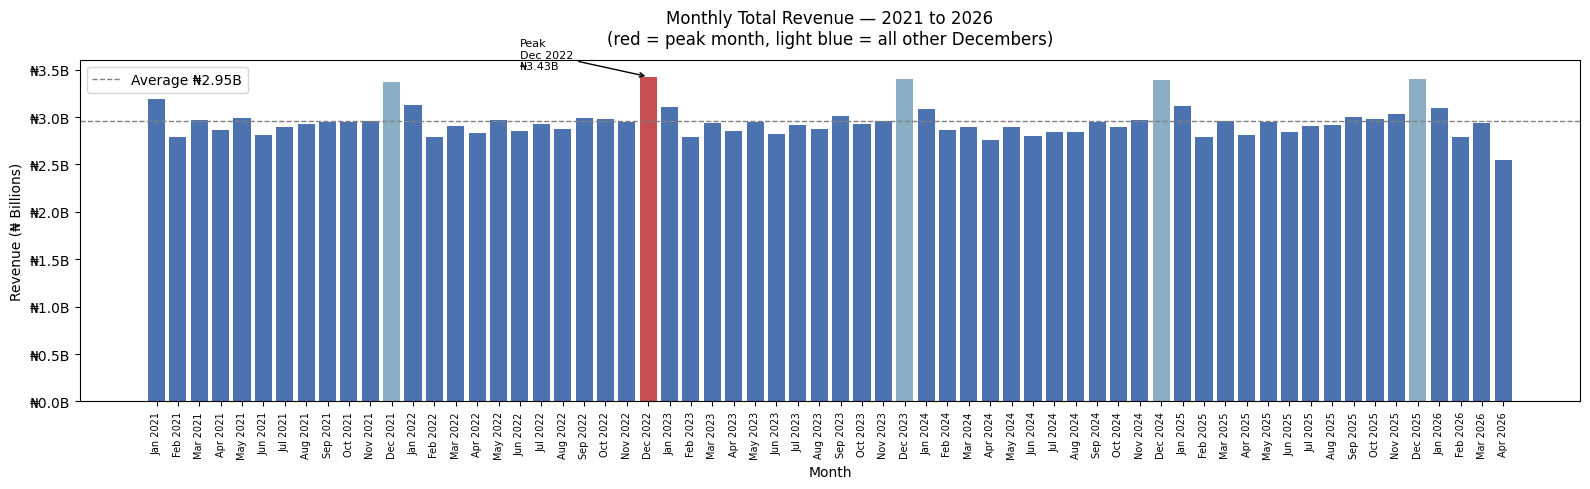

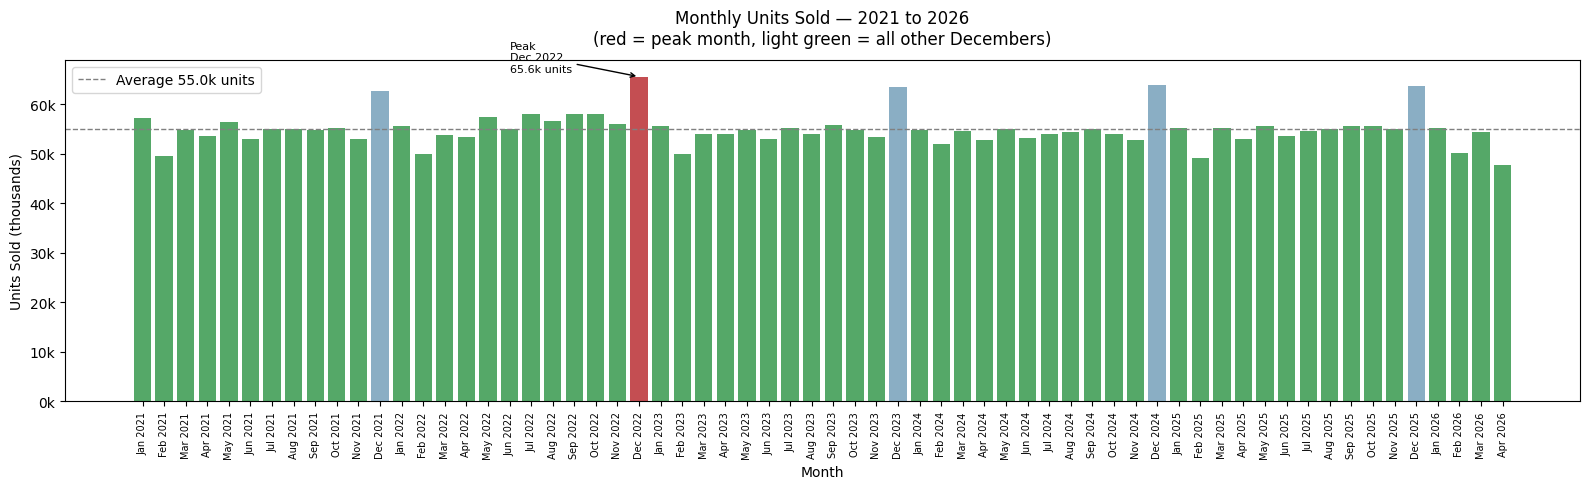

── Revenue ──────────────────────────────────────
  Peak month  : Dec 2022  →  ₦3.425B
  Lowest month: Apr 2026  →  ₦2.550B
  Average     : ₦2.954B / month

── Units Sold ───────────────────────────────────
  Peak month  : Dec 2022  →  65,582 units
  Lowest month: Apr 2026  →  47,832 units
  Average     : 55,025 units / month


In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

mr = monthly_revenue.copy()
mr["month"]           = pd.to_datetime(mr["month"])
mr["month_label"]     = mr["month"].dt.strftime("%b %Y")
mr["year"]            = mr["month"].dt.year
mr["is_december"]     = mr["month"].dt.month == 12
mr["revenue_bn"]      = mr["total_revenue"] / 1e9
mr["units_k"]         = mr["total_units_sold"] / 1e3

peak_rev_idx   = mr["total_revenue"].idxmax()
peak_units_idx = mr["total_units_sold"].idxmax()

rev_colors   = ["#C44E52" if i == peak_rev_idx   else "#8AAEC4" if is_dec else "#4C72B0"
                for i, is_dec in zip(mr.index, mr["is_december"])]
units_colors = ["#C44E52" if i == peak_units_idx else "#8AAEC4" if is_dec else "#55A868"
                for i, is_dec in zip(mr.index, mr["is_december"])]

# ── Chart 1: Total Revenue ────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(mr["month_label"], mr["revenue_bn"], color=rev_colors, width=0.8)

ax.axhline(mr["revenue_bn"].mean(), color="grey", ls="--", lw=1,
           label=f"Average ₦{mr['revenue_bn'].mean():.2f}B")

peak = mr.loc[peak_rev_idx]
ax.annotate(
    f"Peak\n{peak['month_label']}\n₦{peak['revenue_bn']:.2f}B",
    xy=(peak_rev_idx, peak["revenue_bn"]),
    xytext=(peak_rev_idx - 6, peak["revenue_bn"] + 0.08),
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
    fontsize=8, color="black",
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"₦{v:.1f}B"))
ax.set_title("Monthly Total Revenue — 2021 to 2026\n(red = peak month, light blue = all other Decembers)",
             fontsize=12, pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (₦ Billions)")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()

# ── Chart 2: Total Units Sold ─────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(mr["month_label"], mr["units_k"], color=units_colors, width=0.8)

ax.axhline(mr["units_k"].mean(), color="grey", ls="--", lw=1,
           label=f"Average {mr['units_k'].mean():.1f}k units")

peak_u = mr.loc[peak_units_idx]
ax.annotate(
    f"Peak\n{peak_u['month_label']}\n{peak_u['units_k']:.1f}k units",
    xy=(peak_units_idx, peak_u["units_k"]),
    xytext=(peak_units_idx - 6, peak_u["units_k"] + 1),
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
    fontsize=8, color="black",
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}k"))
ax.set_title("Monthly Units Sold — 2021 to 2026\n(red = peak month, light green = all other Decembers)",
             fontsize=12, pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Units Sold (thousands)")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()

# ── Print peak summary ────────────────────────────────────
print("── Revenue ──────────────────────────────────────")
print(f"  Peak month  : {mr.loc[peak_rev_idx, 'month_label']}  →  ₦{mr.loc[peak_rev_idx, 'revenue_bn']:.3f}B")
print(f"  Lowest month: {mr.loc[mr['total_revenue'].idxmin(), 'month_label']}  →  ₦{mr['revenue_bn'].min():.3f}B")
print(f"  Average     : ₦{mr['revenue_bn'].mean():.3f}B / month")
print()
print("── Units Sold ───────────────────────────────────")
print(f"  Peak month  : {mr.loc[peak_units_idx, 'month_label']}  →  {mr.loc[peak_units_idx, 'total_units_sold']:,.0f} units")
print(f"  Lowest month: {mr.loc[mr['total_units_sold'].idxmin(), 'month_label']}  →  {mr['total_units_sold'].min():,.0f} units")
print(f"  Average     : {mr['total_units_sold'].mean():,.0f} units / month")

---
## Insights
> Generated dynamically from the data — re-run this cell after new data is added and figures update automatically.

In [27]:
import textwrap

# ── Compute everything from the data ──────────────────────
avg_rev_bn    = mr["revenue_bn"].mean()
avg_units_k   = mr["units_k"].mean()

peak_rev_row  = mr.loc[mr["revenue_bn"].idxmax()]
peak_unit_row = mr.loc[mr["units_k"].idxmax()]

low_rev_row   = mr.loc[mr["revenue_bn"].idxmin()]
low_unit_row  = mr.loc[mr["units_k"].idxmin()]

dec_months    = mr[mr["is_december"]]
dec_avg_rev   = dec_months["revenue_bn"].mean()
dec_premium   = (dec_avg_rev - avg_rev_bn) / avg_rev_bn * 100

feb_months    = mr[mr["month"].dt.month == 2]
weakest_feb   = feb_months.loc[feb_months["units_k"].idxmin()]

jan_months    = mr[mr["month"].dt.month == 1]
jan_avg_rev   = jan_months["revenue_bn"].mean()

last_month    = mr.iloc[-1]
is_partial    = last_month["month"].day < 28   # catches partial months at the end

# ── Print insights ─────────────────────────────────────────
print("=" * 60)
print("INSIGHTS — auto-generated from current data")
print("=" * 60)

print(f"""
PEAK REVENUE
  Month : {peak_rev_row['month_label']}
  Value : ₦{peak_rev_row['revenue_bn']:.2f}B  ({((peak_rev_row['revenue_bn'] - avg_rev_bn) / avg_rev_bn * 100):.1f}% above average)

PEAK UNITS SOLD
  Month : {peak_unit_row['month_label']}
  Value : {peak_unit_row['units_k']:.1f}k units  ({((peak_unit_row['units_k'] - avg_units_k) / avg_units_k * 100):.1f}% above average)

AVERAGES
  Revenue     : ₦{avg_rev_bn:.2f}B / month
  Units sold  : {avg_units_k:.1f}k / month

DECEMBER EFFECT
  Avg December revenue : ₦{dec_avg_rev:.2f}B  ({dec_premium:.1f}% above monthly average)
  December is the strongest month in all {dec_months['year'].nunique()} years covered.

WEAKEST MONTH (REVENUE)
  Month : {low_rev_row['month_label']}  →  ₦{low_rev_row['revenue_bn']:.2f}B
  {"Note: this may be a partial month — treat with caution." if low_rev_row['month_label'] == last_month['month_label'] else ""}

WEAKEST MONTH (UNITS)
  Month : {low_unit_row['month_label']}  →  {low_unit_row['units_k']:.1f}k units
  {"Note: this may be a partial month — treat with caution." if low_unit_row['month_label'] == last_month['month_label'] else ""}

FEBRUARY PATTERN
  Weakest February : {weakest_feb['month_label']}  →  {weakest_feb['units_k']:.1f}k units
  February consistently dips below average — shortest calendar month + post-Jan slowdown.

JANUARY PATTERN
  Average January revenue : ₦{jan_avg_rev:.2f}B
  {"January is above the monthly average — dry season demand for ACs and Refrigerators." if jan_avg_rev > avg_rev_bn else "January is at or below the monthly average."}

TREND
  Date range  : {mr['month'].min().strftime('%b %Y')} → {mr['month'].max().strftime('%b %Y')}
  Months      : {len(mr)}
  Visible trend : {"No clear upward or downward drift — stable baseline." if abs(mr['revenue_bn'].iloc[-6:].mean() - mr['revenue_bn'].iloc[:6].mean()) < 0.1 else "Possible drift detected — compare first 6 months vs last 6 months."}
""")

INSIGHTS — auto-generated from current data

PEAK REVENUE
  Month : Dec 2022
  Value : ₦3.43B  (16.0% above average)

PEAK UNITS SOLD
  Month : Dec 2022
  Value : 65.6k units  (19.2% above average)

AVERAGES
  Revenue     : ₦2.95B / month
  Units sold  : 55.0k / month

DECEMBER EFFECT
  Avg December revenue : ₦3.40B  (15.0% above monthly average)
  December is the strongest month in all 5 years covered.

WEAKEST MONTH (REVENUE)
  Month : Apr 2026  →  ₦2.55B
  Note: this may be a partial month — treat with caution.

WEAKEST MONTH (UNITS)
  Month : Apr 2026  →  47.8k units
  Note: this may be a partial month — treat with caution.

FEBRUARY PATTERN
  Weakest February : Feb 2025  →  49.2k units
  February consistently dips below average — shortest calendar month + post-Jan slowdown.

JANUARY PATTERN
  Average January revenue : ₦3.12B
  January is above the monthly average — dry season demand for ACs and Refrigerators.

TREND
  Date range  : Jan 2021 → Apr 2026
  Months      : 64
  Visible 